<h2>1. Data Preprocessing</h2>

In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import os
import shutil

path = kagglehub.dataset_download("karkavelrajaj/amazon-sales-dataset")
print("Original cache path:", path)
destination_path = "/content/amazon-sales-dataset"
if not os.path.exists(destination_path):
    shutil.move(path, destination_path)
    print(f"Dataset moved to: {destination_path}")
else:
    print(f"Dataset already exists at: {destination_path}")

df = pd.read_csv('/content/amazon-sales-dataset/amazon.csv')

# 3. Membersihkan kolom Harga (Menghapus simbol '₹' dan ',')
# Kita ubah ke float supaya bisa diolah secara matematis
def clean_price(price):
    if isinstance(price, str):
        return float(price.replace('₹', '').replace(',', ''))
    return price

df['discounted_price'] = df['discounted_price'].apply(clean_price)
df['actual_price'] = df['actual_price'].apply(clean_price)

# 4. Membersihkan kolom Rating
# Ada rating yang isinya '|' atau simbol aneh, kita ubah ke NaN lalu drop
df['rating'] = pd.to_numeric(df['rating'].str.replace('|', 'nan', regex=False), errors='coerce')

# 5. Membersihkan kolom Rating Count (Jumlah orang yang vote)
# Menghapus koma agar bisa jadi integer
df['rating_count'] = pd.to_numeric(df['rating_count'].str.replace(',', ''), errors='coerce')

# 6. Menangani Missing Values
df = df.dropna(subset=['rating', 'rating_count', 'actual_price'])

# 7. Sederhanakan Kategori (Ambil kategori utama saja)
# Contoh: "Computers&Accessories|Accessories&Peripherals|Cables" -> "Computers&Accessories"
df['main_category'] = df['category'].str.split('|').str[0]

# 8. Pilih Kolom Final untuk Hybrid System
cols_final = [
    'product_name', 'main_category',
    'discounted_price', 'rating', 'rating_count', 'about_product'
]
df_amazon = df[cols_final]

print("Preprocessing Selesai!")
print(f"Total Produk Bersih: {len(df_amazon)}")
display(df_amazon.head())

# 9. Simpan hasil data preprocessing ke file CSV
# path_output = '/content/drive/MyDrive/SSI_Project_Kel3/Data/amazon_cleaned.csv'
# df_amazon.to_csv(path_output, index=False)

# print(f"Hasil data preprocessing berhasil disimpan di: {path_output}")

Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.
Original cache path: /kaggle/input/amazon-sales-dataset
Dataset already exists at: /content/amazon-sales-dataset
Preprocessing Selesai!
Total Produk Bersih: 1462


,product_name,main_category,discounted_price,rating,rating_count,about_product
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,399.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories,199.0,4.0,43994.0,"Compatible with all Type C enabled devices, be..."
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories,199.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories,329.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories,154.0,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...


Hasil data preprocessing berhasil disimpan di: /content/drive/MyDrive/SSI_Project_Kel3/Data/amazon_cleaned.csv


<h2>2. TF-IDF </h2>

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TF-IDF
tfidf = TfidfVectorizer(stop_words='english')

# Mengubah deskripsi produk menjadi matriks angka
tfidf_matrix = tfidf.fit_transform(df_amazon['about_product'])

print(f"Matriks TF-IDF terbentuk dengan ukuran: {tfidf_matrix.shape}")

Matriks TF-IDF terbentuk dengan ukuran: (1462, 8908)


<h2>3. Cosine Similarity </h2>

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Menghitung skor kemiripan (range 0 sampai 1)
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [ ]:
def get_hybrid_recommendations(product_name, k=10):
    # 1. Cari index produk berdasarkan nama
    idx = df_amazon[df_amazon['product_name'] == product_name].index[0]

    # 2. Ambil skor kemiripan produk tersebut dengan semua produk lain
    sim_scores = list(enumerate(cosine_sim[idx]))

    # 3. Urutkan berdasarkan kemiripan tertinggi (Proses KNN)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # 4. Ambil 20 kandidat teratas dulu (supaya ada bahan untuk di-sortir lagi)
    top_candidates_idx = [i[0] for i in sim_scores[1:21]]
    top_candidates = df_amazon.iloc[top_candidates_idx].copy()

    # 5. HYBRID LOGIC: Urutkan ulang berdasarkan Rating & Harga
    # Kita cari yang Ratingnya tinggi tapi harganya bersaing
    final_recommendation = top_candidates.sort_values(
        by=['rating', 'discounted_price'],
        ascending=[False, True]
    )

    return final_recommendation.head(k)

# COBA TEST:
print("Rekomendasi untuk produk pertama:")
get_hybrid_recommendations(df_amazon['product_name'].iloc[0])

Rekomendasi untuk produk pertama:


,product_name,main_category,discounted_price,rating,rating_count,about_product
186,AmazonBasics USB C to Lightning Aluminum with ...,Computers&Accessories,949.0,4.4,13552.0,Nylon-braided charging cable with a USB-C powe...
331,"ESR USB C to Lightning Cable, 10 ft (3 m), MFi...",Computers&Accessories,1519.0,4.4,19763.0,MFi Certified: this USB-C to Lightning cable i...
261,Wayona Nylon Braided Usb Type C 3Ft 1M 3A Fast...,Computers&Accessories,325.0,4.2,10576.0,"Usb c to usb a data charging cable, fully comp..."
104,Wayona Nylon Braided USB Data Sync and Fast Ch...,Computers&Accessories,349.0,4.2,13120.0,"[High Compatibility] : iPhones, iPad Air, iPad..."
369,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,399.0,4.2,24270.0,High Compatibility : Compatible With iPhone 12...
614,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,399.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...
42,Wayona Nylon Braided 3A Lightning to USB A Syn...,Computers&Accessories,399.0,4.2,24269.0,"[High Compatibility] : iPhone X/XsMax/Xr ,iPho..."
166,Wayona Nylon Braided Lightning USB Data Sync &...,Computers&Accessories,399.0,4.2,13120.0,"[High Compatibility] : iPhones, iPad Air, iPad..."
80,Wayona Usb Nylon Braided Data Sync And Chargin...,Computers&Accessories,399.0,4.2,24269.0,[High Compatibility] : Compatible For iPhone X...
106,Wayona Nylon Braided 2M / 6Ft Fast Charge Usb ...,Computers&Accessories,449.0,4.2,24269.0,"[High Compatibility] : Phone X/XsMax/Xr ,Phone..."


<h2>Data Visualization</h2>

/tmp/ipykernel_4262/2770801547.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_amazon, x='rating', palette='viridis')
/tmp/ipykernel_4262/2770801547.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='magma')


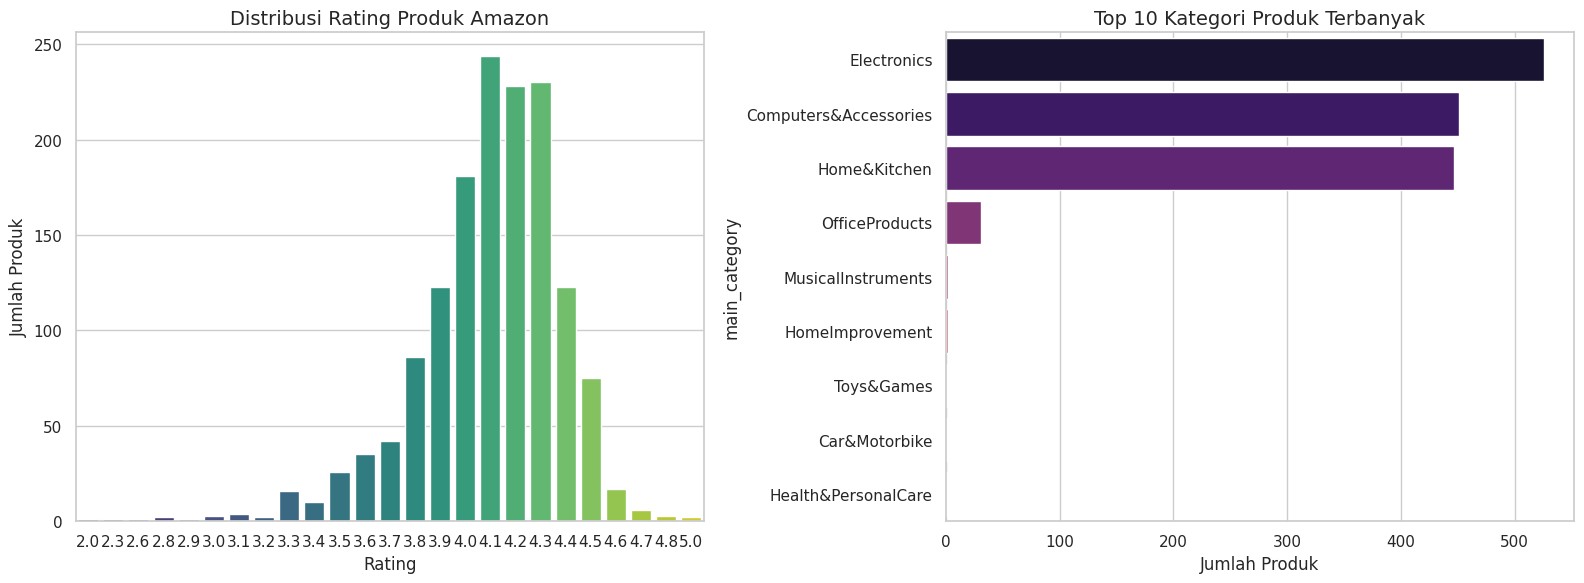

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Mengatur gaya visualisasi
sns.set(style="whitegrid")

# Buat Dashboard 1: Distribusi Rating dan Top Kategori
plt.figure(figsize=(16, 6))

# Subplot 1: Distribusi Rating
plt.subplot(1, 2, 1)
sns.countplot(data=df_amazon, x='rating', palette='viridis')
plt.title('Distribusi Rating Produk Amazon', fontsize=14)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Jumlah Produk', fontsize=12)

# Subplot 2: Top 10 Kategori Utama
plt.subplot(1, 2, 2)
top_categories = df_amazon['main_category'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, palette='magma')
plt.title('Top 10 Kategori Produk Terbanyak', fontsize=14)
plt.xlabel('Jumlah Produk', fontsize=12)

plt.tight_layout()
plt.show()

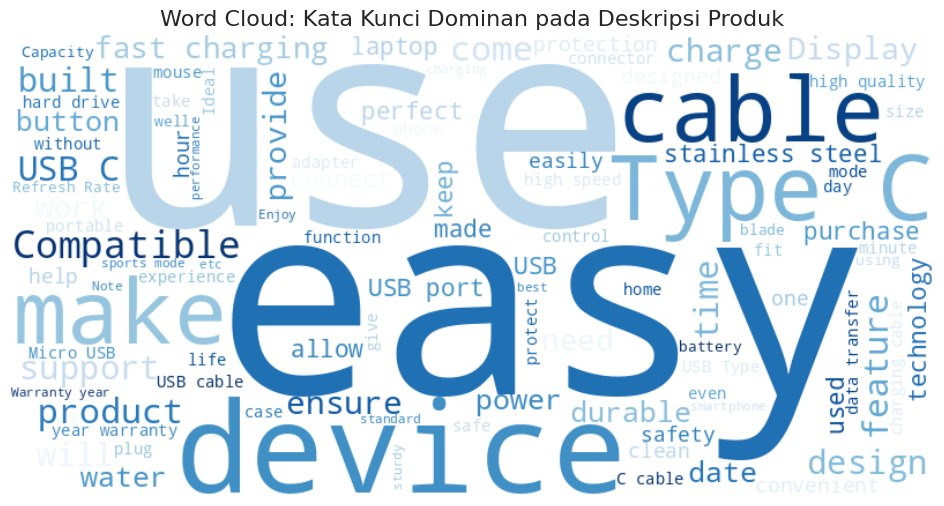

In [ ]:
# Gabungkan semua teks dari kolom about_product menjadi satu string besar
text_data = " ".join(description for description in df_amazon['about_product'].astype(str))

# Buat WordCloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='Blues',
                      max_words=100).generate(text_data)

# Tampilkan WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Menghilangkan garis sumbu
plt.title('Word Cloud: Kata Kunci Dominan pada Deskripsi Produk', fontsize=16)
plt.show()

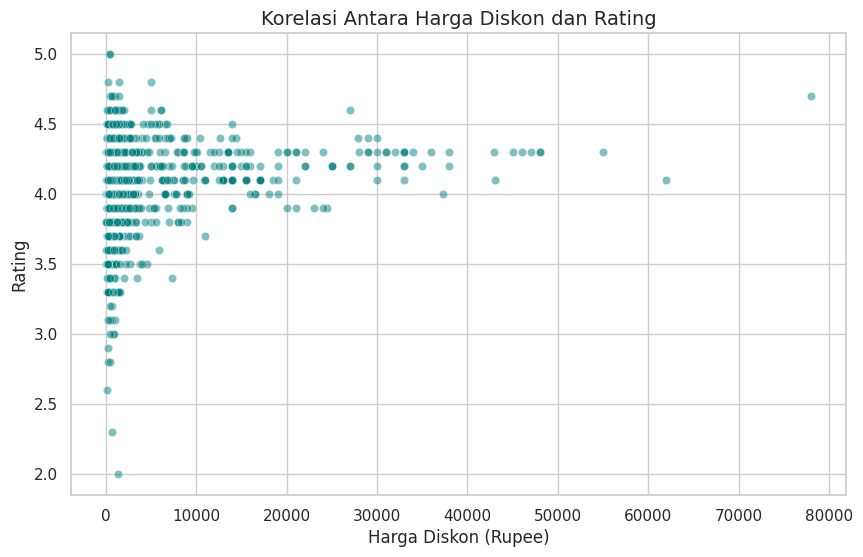

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_amazon, x='discounted_price', y='rating', alpha=0.5, color='teal')
plt.title('Korelasi Antara Harga Diskon dan Rating', fontsize=14)
plt.xlabel('Harga Diskon (Rupee)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()